In [25]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import norm
import time

Keys inside file: ['imageAC']


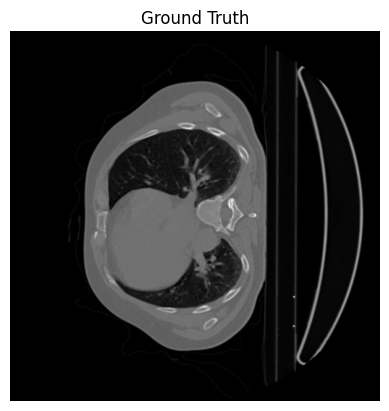

Image size: (512, 512)


In [26]:
file_path = 'data/assignmentMathImagingRecon_chestCT.mat'

with h5py.File(file_path, 'r') as f:
    print("Keys inside file:", list(f.keys()))
    
    gt = np.array(f['imageAC'])  

# gt = gt.T  
# if gt.shape[0] > 128:
#     from skimage.transform import resize
#     gt = resize(gt, (128,128), anti_aliasing=True)

N = gt.shape[0]
x_true = gt.flatten()

plt.imshow(gt, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')
plt.show()

print("Image size:", gt.shape)

In [ ]:
def build_system_matrix_approx(N, angles_deg, ds=1.0):   
    coords = np.arange(N) - (N - 1) / 2.0  
    t_vals = coords.copy()
    max_len = np.sqrt(2) * N
    rows = []
    cols = []
    vals = []
    row_idx = 0
    
    half = (N - 1) / 2.0

    for theta in angles_deg:
        th = np.deg2rad(theta)
        cos_t = np.cos(th)
        sin_t = np.sin(th)

        for t in t_vals:   
            s_vals = np.arange(-max_len, max_len + ds/2.0, ds)            
            x_line = t * cos_t - s_vals * sin_t
            y_line = t * sin_t + s_vals * cos_t
           
            col_coords = np.round(x_line + half).astype(int)
            row_coords = np.round((-y_line) + half).astype(int)  
            valid = (col_coords >= 0) & (col_coords < N) & (row_coords >= 0) & (row_coords < N)
            if not np.any(valid):
                row_idx += 1
                continue

          
            lin_idx = row_coords[valid] * N + col_coords[valid]   
            
            unique_idx, counts = np.unique(lin_idx, return_counts=True)
            rows.extend([row_idx] * unique_idx.size)
            cols.extend(unique_idx.tolist())
            vals.extend((counts * ds).tolist())   
            row_idx += 1

    A = csr_matrix((np.array(vals, dtype=float), (np.array(rows, dtype=int), np.array(cols, dtype=int))),
                   shape=(row_idx, N * N), dtype=np.float64)
    meta = {'M_rows': row_idx, 'Npix': N*N}
    return A, t_vals, meta

In [28]:
x_true = gt.flatten().astype(np.float32)
theta = np.arange(0, 180, 1)
A, t_vals = build_system_matrix(N, theta, ds=1.0)
print("A shape:", A.shape, "nnz:", A.nnz)
b = A @ x_true
intensity_range = float(b.max() - b.min())
sigma = 0.05 * intensity_range
rng = np.random.default_rng(0)  
noise = rng.normal(0.0, sigma, size=b.shape).astype(np.float32)
b_noisy = b + noise

A shape: (92160, 262144) nnz: 42447864


In [29]:
print("b min/max:", b.min(), b.max(), "sigma:", sigma)

b min/max: 0.0 14161.87 sigma: 708.093505859375


In [30]:
def rrmse(x_true, x_est):
    return np.linalg.norm(x_true - x_est) / np.linalg.norm(x_true)

In [31]:
def myART(A, b, x_true=None, lam=0.3, ordering='sequential', max_iter=10, save_intermediate=True):

    M, P = A.shape
    x = np.zeros(P, dtype=np.float32)
    row_norms = np.array(A.power(2).sum(axis=1)).flatten() 
    row_norms[row_norms == 0] = 1.0

    rrmse_list = []
    saved_x = [] if save_intermediate else None

    for it in range(max_iter):
        if ordering == 'sequential':
            order = np.arange(M)
        elif ordering == 'random':
            order = np.random.default_rng(it).permutation(M)
        else:
            raise ValueError("Unknown ordering")

        for i in order:
            row = A.getrow(i)
            if row.nnz == 0:
                continue
            indices = row.indices     
            data = row.data.astype(np.float32)  
            ai_x = np.dot(data, x[indices])
            resid = float(b[i] - ai_x)
            x[indices] += (lam * resid / row_norms[i]) * data

        if x_true is not None:
            r = rrmse(x_true, x)
            rrmse_list.append(r)
            print(f"iter {it+1}/{max_iter}  RRMSE = {r:.6f}")
        else:
            rrmse_list.append(None)

        if save_intermediate:
            saved_x.append(x.copy())

    if save_intermediate:
        return x, rrmse_list, saved_x
    return x, rrmse_list

In [ ]:
import matplotlib.pyplot as plt
import os

lambda_values = np.arange(0.1, 1.01, 0.1)
max_iter = 10
out_dir = "Q4_outputs"
os.makedirs(out_dir, exist_ok=True)

all_rrmse = {}
best_images = {}


for lam in lambda_values:
    print("\n--- Running ART with lambda =", lam)
    x_rec, rrmse_list, saved_x = myART(A, b_noisy, x_true=x_true, lam=lam, ordering='sequential', max_iter=max_iter, save_intermediate=True)
    all_rrmse[lam] = rrmse_list

    recon_img = x_rec.reshape((N, N))
    plt.imsave(os.path.join(out_dir, f"recon_lambda_{lam:.1f}.png"), recon_img, cmap='gray')
    print("saved:", os.path.join(out_dir, f"recon_lambda_{lam:.1f}.png"))


    valid_rrmse = np.array([r if r is not None else np.inf for r in rrmse_list])
    best_iter = np.argmin(valid_rrmse)

    best_x = saved_x[best_iter]
    best_images[lam] = best_x

    print(f"Best iteration for λ={lam:.1f} → iter {best_iter+1}, RRMSE={valid_rrmse[best_iter]:.4f}")


    plt.imsave(os.path.join(out_dir, f"best_recon_lambda_{lam:.1f}.png"),
               best_x.reshape((N, N)), cmap='gray')



--- Running ART with lambda = 0.1
iter 1/10  RRMSE = 0.374198
iter 2/10  RRMSE = 0.308224
iter 3/10  RRMSE = 0.320360
iter 4/10  RRMSE = 0.355884
iter 5/10  RRMSE = 0.397220
iter 6/10  RRMSE = 0.438554
iter 7/10  RRMSE = 0.477970
iter 8/10  RRMSE = 0.514823
iter 9/10  RRMSE = 0.548966
iter 10/10  RRMSE = 0.580467
saved: Q4_outputs/recon_lambda_0.1.png
Best iteration for λ=0.1 → iter 2, RRMSE=0.3082

--- Running ART with lambda = 0.2
iter 1/10  RRMSE = 0.430271
iter 2/10  RRMSE = 0.415912
iter 3/10  RRMSE = 0.470483
iter 4/10  RRMSE = 0.536887
iter 5/10  RRMSE = 0.599598
iter 6/10  RRMSE = 0.654253
iter 7/10  RRMSE = 0.700946
iter 8/10  RRMSE = 0.740757
iter 9/10  RRMSE = 0.774885
iter 10/10  RRMSE = 0.804359
saved: Q4_outputs/recon_lambda_0.2.png
Best iteration for λ=0.2 → iter 2, RRMSE=0.4159

--- Running ART with lambda = 0.30000000000000004
iter 1/10  RRMSE = 0.506474
iter 2/10  RRMSE = 0.543416
iter 3/10  RRMSE = 0.618277
iter 4/10  RRMSE = 0.687734
iter 5/10  RRMSE = 0.746817
ite

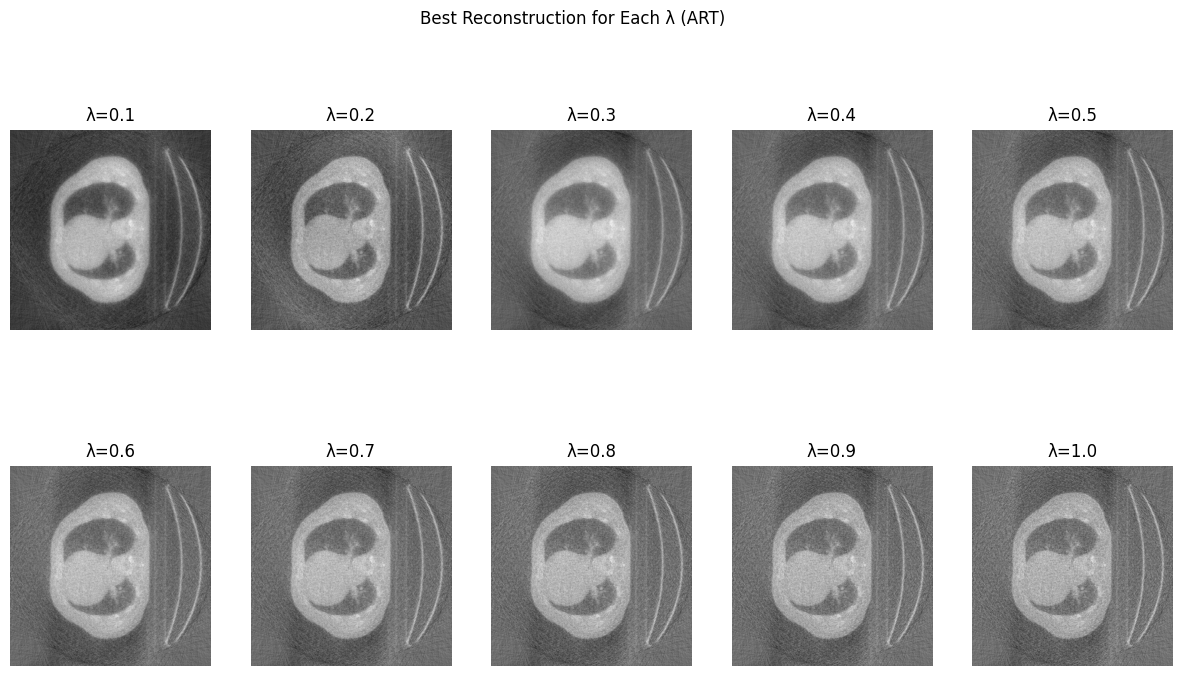

In [35]:
plt.figure(figsize=(15,8))

for i, lam in enumerate(lambda_values):
    plt.subplot(2, 5, i+1)
    plt.imshow(best_images[lam].reshape((N, N)), cmap='gray')
    plt.title(f"λ={lam:.1f}")
    plt.axis('off')

plt.suptitle("Best Reconstruction for Each λ (ART)")
plt.show()

In [36]:
print("A shape:", A.shape, "nnz:", A.nnz)
print("b length:", b.shape)
print("x_true norm:", np.linalg.norm(x_true))
b_test = A @ x_true
print("norm difference between computed b and original b:", np.linalg.norm(b_test - b))

A shape: (92160, 262144) nnz: 42447864
b length: (92160,)
x_true norm: 10962.78
norm difference between computed b and original b: 0.0


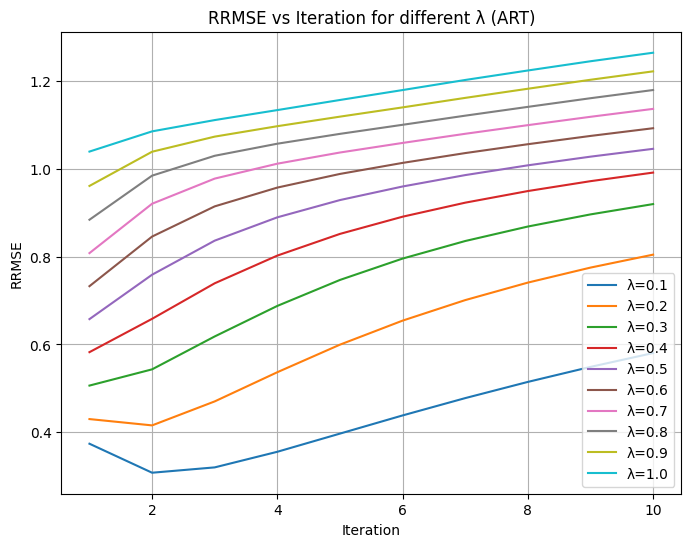

In [37]:
plt.figure(figsize=(8,6))
for lam in lambda_values:
    plt.plot(range(1, max_iter+1), all_rrmse[lam], label=f"λ={lam:.1f}")
plt.xlabel("Iteration")
plt.ylabel("RRMSE")
plt.title("RRMSE vs Iteration for different λ (ART)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(out_dir, "RRMSE_vs_iters.png"), dpi=200)
plt.show()